In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile
import yaml

drive_path = '/content/drive/MyDrive/'
extract_path = '/content/pcb_dataset'

# Automatically scan Drive for your PCB zip archive
found_zip = None
for file in os.listdir(drive_path):
    if file.endswith('.zip') and ('PCB' in file or 'Fault' in file or 'pcb' in file):
        found_zip = os.path.join(drive_path, file)
        break

if found_zip:
    print(f"Found dataset archive at: {found_zip}")
    print("Extracting files to ultra-fast cloud memory... please wait.")

    # Unzip the file
    with zipfile.ZipFile(found_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("SUCCESS: Extraction complete!")

    # Overwrite data.yaml paths dynamically for Google Colab
    yaml_path = os.path.join(extract_path, 'data.yaml')
    config = {
        'path': '/content/pcb_dataset',
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': 6,
        'names': ['missing_hole', 'mouse_bite', 'open_circuit', 'short_circuit', 'spur', 'spurious_copper']
    }
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    print("SUCCESS: data.yaml configured for cloud training!")

else:
    print("❌ ERROR: Could not find any ZIP file containing 'PCB' or 'Fault' in your main Google Drive folder.")

Found dataset archive at: /content/drive/MyDrive/PCB%20Fault%20Detection.v2-pcb-defect-with-aug.yolov8.zip
Extracting files to ultra-fast cloud memory... please wait.
SUCCESS: Extraction complete!
SUCCESS: data.yaml configured for cloud training!


In [3]:
# 1. Install the required Ultralytics framework
!pip install ultralytics

from ultralytics import YOLO

# 2. Initialize the pre-trained nano architecture base
model = YOLO('yolov8n.pt')

# 3. Launch optimized ultra-fast training
results = model.train(
    data='/content/pcb_dataset/data.yaml',
    epochs=15,          # Fast 15-epoch target
    imgsz=416,          # Optimized image size for quick calculations
    batch=32,           # Parallel processing batch size
    workers=4,          # Multithreaded data loading
    device=0            # Directs execution to the T4 GPU
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pcb_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, e


image 1/1 /content/pcb_dataset/test/images/light_05_mouse_bite_02_3_600_jpg.rf.5a706f5cef73626a163446c675526524.jpg: 416x416 1 mouse_bite, 7.1ms
Speed: 2.1ms preprocess, 7.1ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict-2


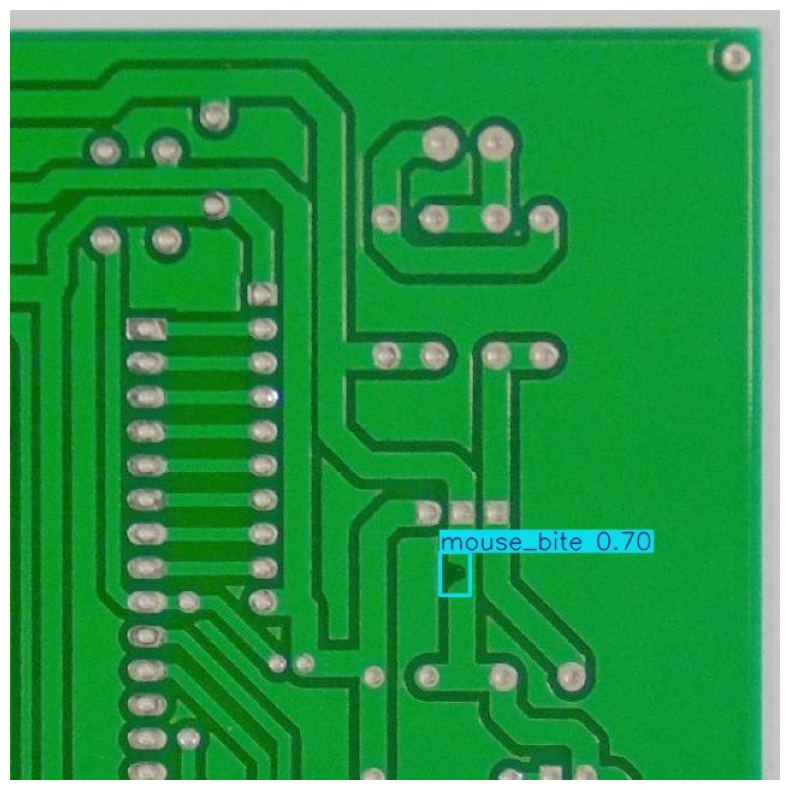

In [5]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load the final model weights generated by your 15-epoch run
my_pcb_model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Grab a completely unseen PCB image from the test set
test_folder = '/content/pcb_dataset/test/images/'
random_file = random.choice(os.listdir(test_folder))
test_image_path = os.path.join(test_folder, random_file)

# 3. Detect the circuit board faults
results = my_pcb_model.predict(source=test_image_path, save=True, imgsz=416)

# 4. Display the output directly on screen with bounding boxes
predicted_folder = results[0].save_dir
output_image_path = os.path.join(predicted_folder, random_file)
output_img = cv2.imread(output_image_path)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


image 1/1 /content/pcb_dataset/test/images/rotation_270_light_07_mouse_bite_06_2_600_jpg.rf.13498574c43229e9015eb17b3bdb6af3.jpg: 416x416 1 mouse_bite, 7.9ms
Speed: 2.0ms preprocess, 7.9ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict-3


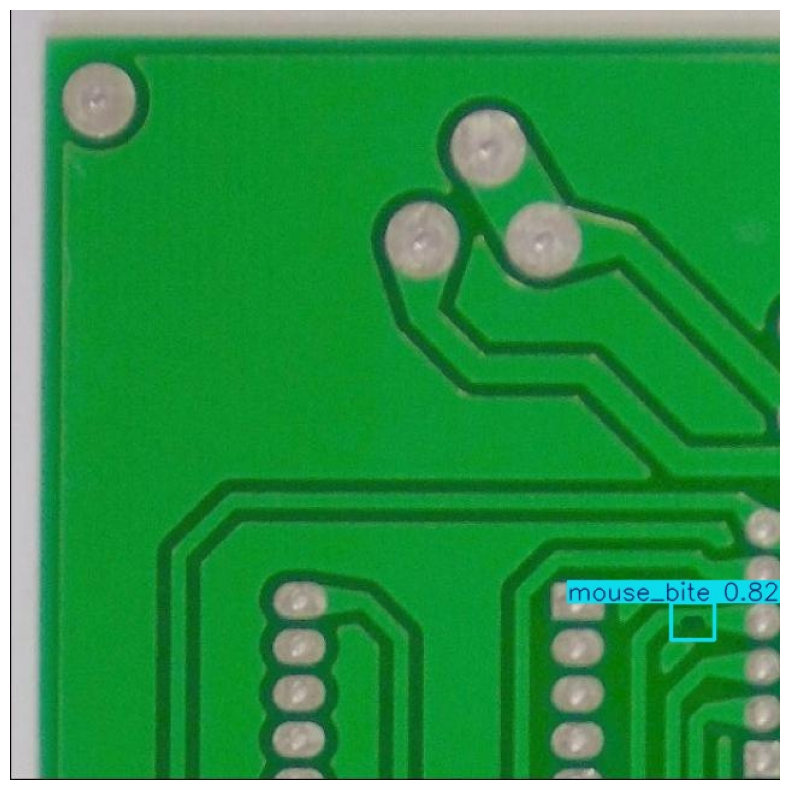


📋 PCB DEFECT ANALYSIS REPORT FOR: rotation_270_light_07_mouse_bite_06_2_600_jpg.rf.13498574c43229e9015eb17b3bdb6af3.jpg
❌ ANALYSIS FAILED: Detected 1 manufacturing anomaly/anomalies.

Defect Breakdown:
  • Found [ Mouse Bite ] with 82.22% confidence.

Summary Count:
  - Mouse Bite: 1


In [6]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load the final model weights
my_pcb_model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Grab a completely unseen PCB image from the test set
test_folder = '/content/pcb_dataset/test/images/'
random_file = random.choice(os.listdir(test_folder))
test_image_path = os.path.join(test_folder, random_file)

# 3. Detect the circuit board faults
results = my_pcb_model.predict(source=test_image_path, save=True, imgsz=416)

# 4. Display the image with bounding boxes
predicted_folder = results[0].save_dir
output_image_path = os.path.join(predicted_folder, random_file)
output_img = cv2.imread(output_image_path)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# ============================================================
# NEW: Extract and print the textual explanation of defects
# ============================================================
print("\n" + "="*50)
print(f"📋 PCB DEFECT ANALYSIS REPORT FOR: {random_file}")
print("="*50)

# Get names dictionary from the model
class_names = results[0].names
detected_boxes = results[0].boxes

if len(detected_boxes) == 0:
    print("✅ ANALYSIS PASSED: No manufacturing defects were detected on this PCB.")
else:
    print(f"❌ ANALYSIS FAILED: Detected {len(detected_boxes)} manufacturing anomaly/anomalies.\n")
    print("Defect Breakdown:")

    # Track counts of each defect type found
    defect_counts = {}
    for box in detected_boxes:
        class_id = int(box.cls[0])
        class_name = class_names[class_id]
        confidence = float(box.conf[0]) * 100

        # Format the defect name cleanly for presentation
        clean_name = class_name.replace('_', ' ').title()
        print(f"  • Found [ {clean_name} ] with {confidence:.2f}% confidence.")

        defect_counts[clean_name] = defect_counts.get(clean_name, 0) + 1

    print("\nSummary Count:")
    for defect, count in defect_counts.items():
        print(f"  - {defect}: {count}")

print("="*50)

👇 CLICK THE BUTTON BELOW TO UPLOAD A PCB IMAGE FROM YOUR DOWNLOADS FOLDER 👇
--------------------------------------------------------------------------------


Saving image.jpg to image (1).jpg
--------------------------------------------------------------------------------
🔄 Upload successful! Analyzing target image: image (1).jpg...

image 1/1 /content/image (1).jpg: 288x416 1 missing_hole, 1 short_circuit, 44.1ms
Speed: 1.4ms preprocess, 44.1ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 416)
Results saved to /content/runs/detect/predict-6


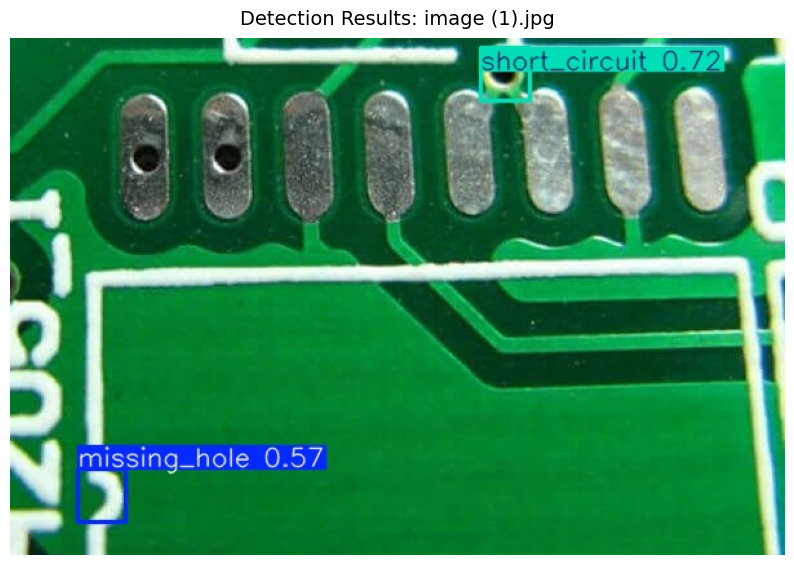


📋 PCB DEFECT ANALYSIS REPORT FOR: image (1).jpg
❌ ANALYSIS FAILED: Detected 2 manufacturing anomaly/anomalies.

Defect Breakdown:
  • Found [ Short Circuit ] with 72.34% confidence.
  • Found [ Missing Hole ] with 57.03% confidence.

Summary Count:
  - Short Circuit: 1
  - Missing Hole: 1


In [16]:
import os
import cv2
import shutil
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

# 1. Verify model weights exist
weights_path = '/content/runs/detect/train/weights/best.pt'

if not os.path.exists(weights_path):
    print("❌ ERROR: Could not find your trained model weights at 'best.pt'.")
    print("Make sure your 15-epoch training finished successfully in this session.")
else:
    my_pcb_model = YOLO(weights_path)

    print("👇 CLICK THE BUTTON BELOW TO UPLOAD A PCB IMAGE FROM YOUR DOWNLOADS FOLDER 👇")
    print("-" * 80)

    # 2. Trigger a live browser upload window
    uploaded = files.upload()
    print("-" * 80)

    if len(uploaded) == 0:
        print("❌ Upload cancelled. No file selected.")
    else:
        # Get the name of the file you just uploaded
        uploaded_filename = list(uploaded.keys())[0]
        external_image_path = os.path.join('/content/', uploaded_filename)

        print(f"🔄 Upload successful! Analyzing target image: {uploaded_filename}...")

        # 3. Run YOLOv8 detection
        results = my_pcb_model.predict(source=external_image_path, save=True, imgsz=416)

        # 4. Display the visual result with bounding boxes
        predicted_folder = results[0].save_dir
        output_image_path = os.path.join(predicted_folder, uploaded_filename)
        output_img = cv2.imread(output_image_path)

        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Detection Results: {uploaded_filename}", fontsize=14, pad=10)
        plt.show()

        # 5. Print out the textual defect report
        print("\n" + "="*50)
        print(f"📋 PCB DEFECT ANALYSIS REPORT FOR: {uploaded_filename}")
        print("="*50)

        class_names = results[0].names
        detected_boxes = results[0].boxes

        if len(detected_boxes) == 0:
            print("✅ ANALYSIS PASSED: No manufacturing defects were detected on this PCB.")
        else:
            print(f"❌ ANALYSIS FAILED: Detected {len(detected_boxes)} manufacturing anomaly/anomalies.\n")
            print("Defect Breakdown:")

            defect_counts = {}
            for box in detected_boxes:
                class_id = int(box.cls[0])
                class_name = class_names[class_id]
                confidence = float(box.conf[0]) * 100

                clean_name = class_name.replace('_', ' ').title()
                print(f"  • Found [ {clean_name} ] with {confidence:.2f}% confidence.")

                defect_counts[clean_name] = defect_counts.get(clean_name, 0) + 1

            print("\nSummary Count:")
            for defect, count in defect_counts.items():
                print(f"  - {defect}: {count}")
        print("="*50)

        # Optional: Clean up the uploaded raw image to keep workspace tidy
        try:
            os.remove(external_image_path)
        except:
            pass